# ELMo 문맥 임베딩

**ELMo(Embeddings from Language Models, 엘모)** 는 사전학습한 양방향 언어 모델의 내부 표현을 이용해 단어마다 문맥이 반영된 벡터를 만드는 임베딩 방법이다. 같은 단어라도 주변 단어가 달라지면 서로 다른 벡터를 만든다는 점이 핵심이다.

## 왜 필요한가

Word2Vec 같은 **정적 임베딩**은 단어 하나에 벡터 하나를 저장한다. 따라서 `은행에 돈을 맡겼다`의 금융기관 `은행`과 `강가의 은행에 앉았다`의 강가 `은행`을 같은 벡터로 표현한다. ELMo의 **문맥 임베딩**은 문장 전체의 앞뒤 정보를 반영하므로 같은 철자의 두 `은행`을 서로 다른 벡터로 표현할 수 있다.

## ELMo가 문맥 벡터를 만드는 과정

```text
단어의 문자 ID
   ↓ 문자 CNN
문자 조합이 반영된 단어 벡터
   ↓ 정방향 LM + 역방향 LM
앞 문맥과 뒤 문맥이 반영된 층별 벡터
   ↓ 층별 가중합
현재 과제에 사용할 최종 ELMo 벡터
```

- **문자 CNN**: 단어를 구성하는 문자 패턴에서 기본 단어 표현을 만든다.
- **정방향 언어 모델(Forward LM)**: 왼쪽에서 오른쪽으로 읽으며 이전 단어 정보로 다음 단어를 예측한다.
- **역방향 언어 모델(Backward LM)**: 오른쪽에서 왼쪽으로 읽으며 뒤쪽 단어 정보로 이전 단어를 예측한다.
- **층별 가중합(Weighted Sum)**: 문자층과 여러 LSTM 층의 벡터를 현재 분류·개체명 인식 같은 downstream task에 알맞은 비율로 섞는다.

## 특징과 한계

ELMo는 다의어를 문맥에 따라 구분하고, 학습된 문자 사전에 있는 글자로 이루어진 새 단어도 문자 조합으로 표현할 수 있다. 문장 분류, 개체명 인식과 질의응답 모델의 입력 표현을 보강하는 데 사용됐다.

반면 LSTM이 토큰을 순서대로 처리하므로 병렬 계산이 어렵고, 정방향과 역방향 언어 모델을 별도로 학습한다. 이후 등장한 BERT도 문맥 임베딩을 만들지만 WordPiece와 Transformer Encoder를 사용한다는 차이가 있다.

## 이 노트북에서 확인할 내용

두 문장에 포함된 `은행`을 문자 ID로 변환하고 작은 양방향 언어 모델을 학습한다. 이후 문자층에서는 같았던 두 `은행` 벡터가 앞뒤 문맥을 거친 뒤 달라지는지 확인하고, 언어 모델 학습과 downstream 층 혼합 학습의 경계도 구분한다.


## 1. Word2Vec, ELMo, BERT 비교

**Word2Vec**은 단어를 기본 단위로 사용하고 문맥화를 하지 않는다. 같은 단어에는 항상 같은 벡터를 주며, downstream 모델은 이 정적 임베딩을 입력으로 사용한다.

**ELMo**는 문자 CNN으로 단어 표현을 만든 뒤 양방향 LSTM으로 문맥화한다. 같은 단어도 문장마다 다른 벡터를 만들고, 보통 사전학습 LM은 고정한 채 downstream task가 층 가중합을 학습한다.

**BERT**는 WordPiece를 기본 단위로 사용하고 양방향 Transformer Encoder로 문맥화한다. downstream task에 따라 Encoder 일부 또는 전체와 task head를 함께 미세조정할 수 있다.

ELMo에서 양방향이라는 말은 하나의 LSTM이 미래 target을 미리 본다는 뜻이 아니다. 정방향 LM은 과거로 다음 토큰을 예측하고, 역방향 LM은 미래로 이전 토큰을 예측한 뒤 같은 원래 위치에서 두 표현을 결합한다.


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(42)

sentences = [
    ["<bos>", "나는", "은행", "에", "돈을", "맡겼다", "<eos>"],
    ["<bos>", "나는", "강가", "은행", "에", "앉았다", "<eos>"],
]
# 중복을 제거한 단어·문자 사전을 만들고 각 항목에 정수 ID를 부여한다.
words = sorted({word for sentence in sentences for word in sentence})
word_to_id = {word: index for index, word in enumerate(words)}
characters = sorted({character for word in words for character in word})
char_to_id = {
    character: index + 1 for index, character in enumerate(characters)
}
max_char_length = max(len(word) for word in words)

# word_ids는 다음·이전 단어 예측의 정답이고 char_ids는 문자 CNN의 입력이다.
word_ids = torch.tensor(
    [[word_to_id[word] for word in sentence] for sentence in sentences]
)
char_ids = torch.zeros(
    len(sentences), len(sentences[0]), max_char_length, dtype=torch.long
)

# 문자 padding ID는 0이다.
for batch_index, sentence in enumerate(sentences):
    for token_index, word in enumerate(sentence):
        encoded_word = [char_to_id[character] for character in word]
        char_ids[batch_index, token_index, : len(encoded_word)] = torch.tensor(
            encoded_word
        )

print("word_ids shape:", tuple(word_ids.shape))
print("char_ids shape:", tuple(char_ids.shape))
print("은행 positions:", sentences[0].index("은행"), sentences[1].index("은행"))


word_ids shape: (2, 7)
char_ids shape: (2, 7, 5)
은행 positions: 2 3


## 2. 문자 CNN과 두 방향의 언어 모델

CharacterEncoder는 단어 내부 문자 임베딩에 1차원 합성곱을 적용하고 max pooling으로 단어당 하나의 벡터를 만든다. 학습된 문자 사전에 있는 글자로 이루어진 단어라면, 단어 사전에 등록되지 않았어도 문자 조합으로 표현할 수 있다. 현재 예제는 문자 OOV 처리까지 구현하지 않았으므로 문자 사전에 없는 글자는 별도 OOV 문자 ID가 필요하다.

TinyBiLM은 정방향 LSTM 두 층과 역방향 LSTM 두 층을 별도 파라미터로 유지한다. 역방향 입력을 뒤집어 계산한 뒤 다시 원래 순서로 복원해야 같은 토큰 위치의 정방향 표현과 연결할 수 있다. ELMo 층은 문자층과 각 LSTM 층의 정방향·역방향 표현을 마지막 feature 축에서 결합한 것이다.


In [2]:
class CharacterEncoder(nn.Module):
    def __init__(self, char_vocab_size, char_dim=8, output_dim=16):
        super().__init__()
        self.embedding = nn.Embedding(
            char_vocab_size, char_dim, padding_idx=0
        )
        self.conv = nn.Conv1d(
            char_dim, output_dim, kernel_size=3, padding=1
        )

    def forward(self, character_ids):
        batch_size, token_count, char_length = character_ids.shape
        # `(B,T,C)`를 토큰 묶음으로 펼친 뒤 Conv1d 입력 `(B*T, char_dim, C)`로 바꾼다.
        embedded = self.embedding(
            character_ids.reshape(batch_size * token_count, char_length)
        ).transpose(1, 2)
        # 문자 위치별 특징 중 최댓값만 남겨 토큰마다 하나의 문자 CNN 벡터를 만든다.
        features = torch.relu(self.conv(embedded)).max(dim=-1).values
        return features.reshape(batch_size, token_count, -1)


class TinyBiLM(nn.Module):
    def __init__(self, char_vocab_size, vocab_size, representation_dim=16):
        super().__init__()
        self.char_encoder = CharacterEncoder(
            char_vocab_size, output_dim=representation_dim
        )
        self.forward_layer1 = nn.LSTM(
            representation_dim, representation_dim, batch_first=True
        )
        self.forward_layer2 = nn.LSTM(
            representation_dim, representation_dim, batch_first=True
        )
        self.backward_layer1 = nn.LSTM(
            representation_dim, representation_dim, batch_first=True
        )
        self.backward_layer2 = nn.LSTM(
            representation_dim, representation_dim, batch_first=True
        )
        self.forward_lm = nn.Linear(representation_dim, vocab_size)
        self.backward_lm = nn.Linear(representation_dim, vocab_size)
        self.layer_logits = nn.Parameter(torch.zeros(3))
        self.gamma = nn.Parameter(torch.tensor(1.0))

    def directional_layers(self, character_ids):
        char_layer = self.char_encoder(character_ids)
        forward1, _ = self.forward_layer1(char_layer)
        forward2, _ = self.forward_layer2(forward1)

        # 토큰 순서를 뒤집어 역방향 LSTM을 계산하고 다시 원래 위치 순서로 복원한다.
        reversed_char_layer = torch.flip(char_layer, dims=[1])
        backward1_reversed, _ = self.backward_layer1(reversed_char_layer)
        backward2_reversed, _ = self.backward_layer2(backward1_reversed)
        backward1 = torch.flip(backward1_reversed, dims=[1])
        backward2 = torch.flip(backward2_reversed, dims=[1])
        return char_layer, (forward1, forward2), (backward1, backward2)

    # 두 문자층 forward_layers, backward_layers의 방향별 출력을 받아 ELMo가 섞을 새 표현을 준비
    def elmo_layers(self, character_ids):
        char_layer, forward_layers, backward_layers = self.directional_layers(
            character_ids
        )
        # 정방향 H개와 역방향 H개 특징을 연결해 각 층을 `(B,T,2H)`로 맞춘다.
        token_layer = torch.cat([char_layer, char_layer], dim=-1)
        layer1 = torch.cat(
            [forward_layers[0], backward_layers[0]], dim=-1
        )
        layer2 = torch.cat(
            [forward_layers[1], backward_layers[1]], dim=-1
        )
        return [token_layer, layer1, layer2]

    def contextual_embedding(self, character_ids):
        layers = self.elmo_layers(character_ids)
        # 세 층의 점수를 합이 1인 비율로 바꾸고 같은 위치의 벡터끼리 가중합한다.
        weights = torch.softmax(self.layer_logits, dim=0)
        mixed = sum(
            weight * layer for weight, layer in zip(weights, layers)
        )
        # gamma: 섞은 벡터의 전체 크기를 조절하는 값
        return self.gamma * mixed, weights, layers


model = TinyBiLM(len(char_to_id) + 1, len(word_to_id))
layers = model.elmo_layers(char_ids)
print("ELMo layer shapes:", [tuple(layer.shape) for layer in layers])


ELMo layer shapes: [(2, 7, 32), (2, 7, 32), (2, 7, 32)]


## 3. BiLM loss가 학습하는 파라미터

정방향 마지막 state의 위치 `t`는 `t+1` 토큰을, 역방향 state의 위치 `t`는 `t-1` 토큰을 예측한다. 두 방향은 target 토큰을 입력 문맥으로 미리 보지 않도록 서로 반대 방향으로 shift한다.

중요한 경계는 `layer_logits`와 `gamma`가 아래 BiLM loss 계산에 사용되지 않는다는 점이다. 따라서 이 파라미터를 optimizer에 넣어도 gradient가 생기지 않는다. 이 교안은 혼동을 막기 위해 BiLM optimizer에서 두 파라미터를 명시적으로 제외한다. 실제 ELMo에서는 사전학습한 BiLM을 고정한 뒤 downstream task loss가 층 가중치와 `gamma`를 학습한다.


In [3]:
# BiLM loss에 사용하지 않는 층 혼합값 layer_logits와 gamma는 optimizer에서 제외한다.
lm_parameters = [
    parameter
    for name, parameter in model.named_parameters()
    if name not in {"layer_logits", "gamma"}
]
optimizer = torch.optim.Adam(lm_parameters, lr=0.02)

for epoch in range(1, 61):
    model.train()
    optimizer.zero_grad()
    _, forward_layers, backward_layers = model.directional_layers(char_ids)

    # 두 방향은 target을 반대쪽으로 한 칸 shift한다.
    forward_logits = model.forward_lm(forward_layers[-1][:, :-1, :])
    forward_targets = word_ids[:, 1:]
    backward_logits = model.backward_lm(backward_layers[-1][:, 1:, :])
    backward_targets = word_ids[:, :-1]

    # 문장 축과 토큰 위치 축을 펼쳐 각 위치의 어휘 로짓과 정답 ID를 비교한다.
    forward_loss = F.cross_entropy(
        forward_logits.reshape(-1, len(word_to_id)),
        forward_targets.reshape(-1),
    )
    backward_loss = F.cross_entropy(
        backward_logits.reshape(-1, len(word_to_id)),
        backward_targets.reshape(-1),
    )
    loss = forward_loss + backward_loss
    # 두 방향 loss로 기울기를 계산하고 크기를 제한한 뒤 BiLM 파라미터를 갱신한다.
    loss.backward()
    torch.nn.utils.clip_grad_norm_(lm_parameters, max_norm=1.0)
    optimizer.step()

    if epoch == 1 or epoch % 20 == 0:
        print(f"epoch={epoch:02d}, bidirectional_lm_loss={loss.item():.4f}")

print("forward logits/target:", forward_logits.shape, forward_targets.shape)
print("backward logits/target:", backward_logits.shape, backward_targets.shape)
print("layer_logits.grad:", model.layer_logits.grad)
print("gamma.grad:", model.gamma.grad)


epoch=01, bidirectional_lm_loss=4.4285
epoch=20, bidirectional_lm_loss=1.6503
epoch=40, bidirectional_lm_loss=0.3808
epoch=60, bidirectional_lm_loss=0.2626
forward logits/target: torch.Size([2, 6, 9]) torch.Size([2, 6])
backward logits/target: torch.Size([2, 6, 9]) torch.Size([2, 6])
layer_logits.grad: None
gamma.grad: None


## 4. 층 가중합으로 문맥 임베딩 만들기

각 ELMo 층은 shape `(B, T, 2H)`를 가진다. `softmax(layer_logits)`는 세 층의 합이 1인 가중치를 만들고, `gamma`는 전체 크기를 조절한다. 현재 코드는 downstream loss를 정의하지 않았으므로 가중치는 초기 균등값, `gamma`는 1에 머문다.

같은 철자의 `은행`은 문자층에서 동일하지만, 두 문장의 주변 단어가 다르므로 LM 층을 거친 문맥 벡터는 달라진다. 작은 두 문장 학습의 cosine 값은 품질 지표가 아니라 정적 문자 표현과 문맥화 표현이 달라지는 구조를 확인하는 관찰값이다.


In [4]:
model.eval()
with torch.no_grad():
    contextual, layer_weights, layers = model.contextual_embedding(char_ids)

finance_position = sentences[0].index("은행")
river_position = sentences[1].index("은행")

# 같은 철자의 문자층 벡터와 문맥을 섞은 최종 벡터의 cosine similarity를 비교한다.
character_similarity = F.cosine_similarity(
    layers[0][0, finance_position],
    layers[0][1, river_position],
    dim=0,
).item()
context_similarity = F.cosine_similarity(
    contextual[0, finance_position],
    contextual[1, river_position],
    dim=0,
).item()

print("contextual shape:", tuple(contextual.shape))
print("fixed layer weights:", layer_weights.tolist())
print("fixed gamma:", model.gamma.item())
print(f"same spelling character similarity: {character_similarity:.4f}")
print(f"different context similarity: {context_similarity:.4f}")


contextual shape: (2, 7, 32)
fixed layer weights: [0.3333333432674408, 0.3333333432674408, 0.3333333432674408]
fixed gamma: 1.0
same spelling character similarity: 1.0000
different context similarity: 0.9684


## ELMo 전체 흐름 정리

문자 CNN과 두 방향의 LM이 층별 문맥 표현을 만들고, downstream task는 각 층의 가중치와 `gamma`를 학습해 필요한 표현을 선택한다.

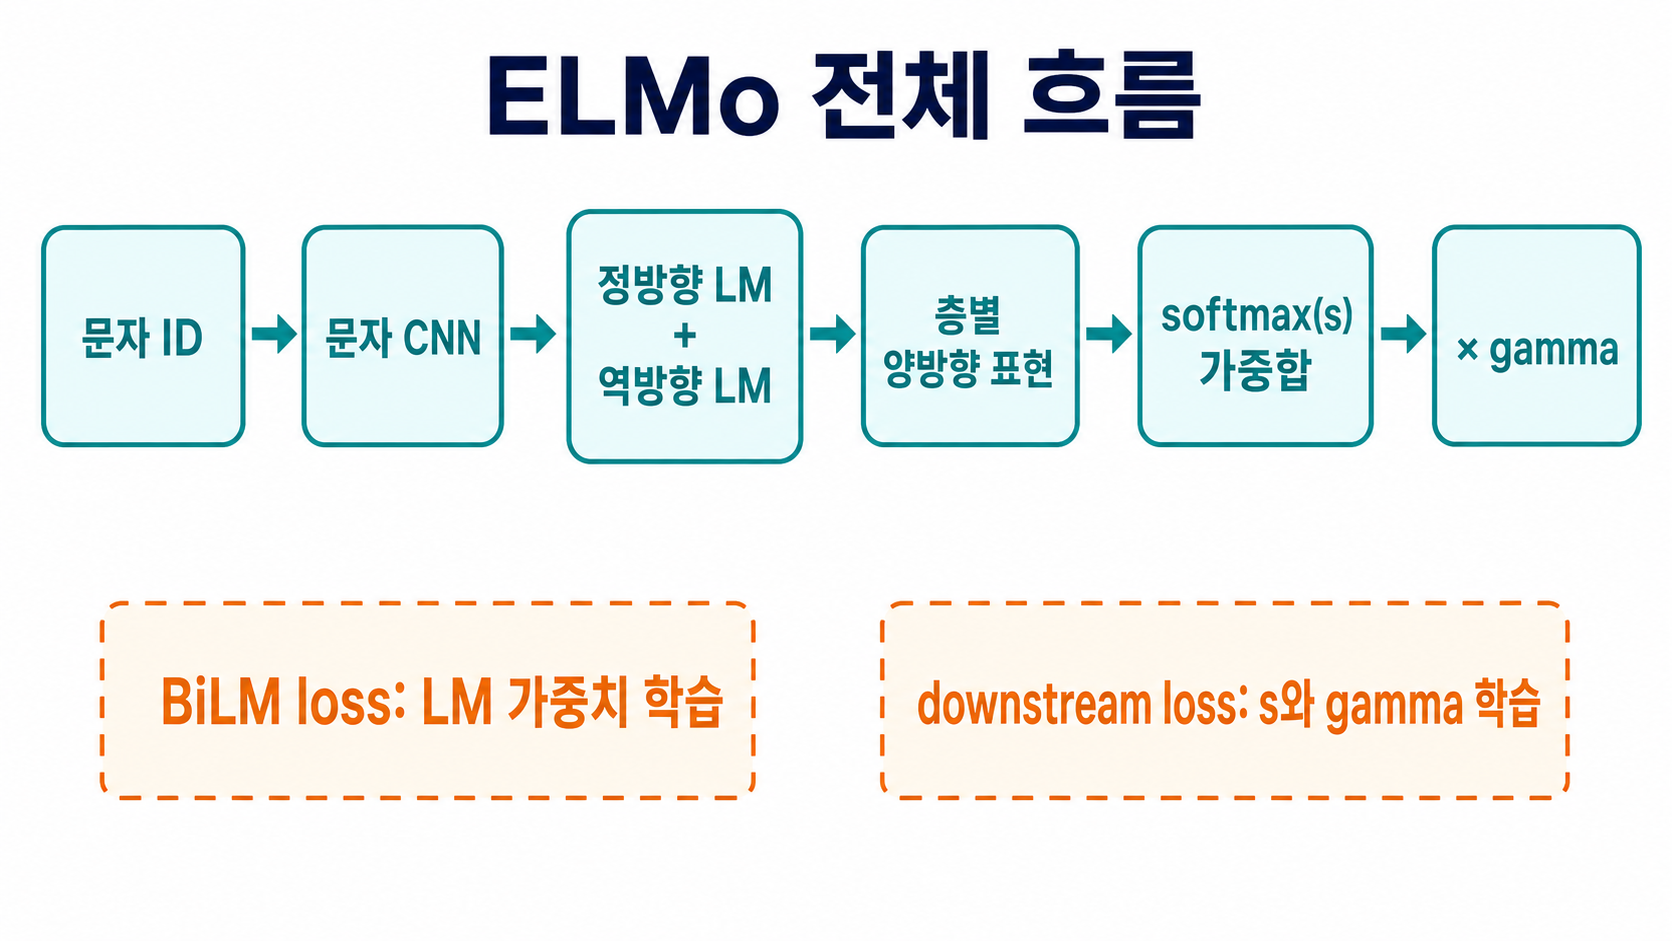
